# Метрическая классификация. Метод ближайших соседей и его развитие
# Практическая работа

## Цели практической работы
Научиться:
- строить модель методом ближайших соседей на реальных данных;
- правильно определять качество работы модели.


## Что входит в практическую работу


- Загрузить данные и ознакомиться с ними.
- Изучить данные и провести анализ.
- Разделить данные на обучающую и тестовую выборки.
- Реализовать построение модели с помощью  библиотеки Scikit-learn.
- Подобрать оптимальное число ближайших соседей методом leave-one-out.
- Получить качество модели с помощью F-меры и матрицы сопряжённости.

## Что оценивается

1. Выполнение всех этапов работы.
2. Наличие вывода по результатам.
3. Непереобученность модели.
4. Качество модели.


**Как отправить работу на проверку?**

1. Скачайте файл с заданием в материалах, откройте его через Jupyter Notebook и выполните задачу. 
2. Сохраните изменения при помощи опции Save and Checkpoint из вкладки File или кнопки Save and Checkpoint на панели инструментов. 
3. Отправьте через форму ниже итоговый файл Jupyter Notebook (в формате .ipynb) или ссылку на него.




# Задача

Один из способов повысить эффективность взаимодействия банка с клиентами — отправлять предложение о новой услуге не всем клиентам, а только некоторым, которые выбираются по принципу наибольшей склонности к отклику на это предложение.

Задача заключается в том, чтобы предложить алгоритм, который будет выдавать склонность клиента к положительному или отрицательному отклику на предложение банка. Предполагается, что, получив такие оценки для некоторого множества клиентов, банк обратится с предложением только к тем, от кого ожидается положительный отклик.


Для решения этой задачи загрузите дамп базы в Postgres. 
Эта БД хранит информацию о клиентах банка и их персональные данные, такие как пол, количество детей и другие.

Описание таблиц с данными представлено ниже.


**D_work**

Описание статусов относительно работы:
- ID — идентификатор социального статуса клиента относительно работы;
- COMMENT — расшифровка статуса.


**D_pens**

Описание статусов относительно пенсии:
- ID — идентификатор социального статуса;
- COMMENT — расшифровка статуса.


**D_clients**

Описание данных клиентов:
- ID — идентификатор записи;
- AGE	— возраст клиента;
- GENDER — пол клиента (1 — мужчина, 0 — женщина);
- EDUCATION — образование;
- MARITAL_STATUS — семейное положение;
- CHILD_TOTAL	— количество детей клиента;
- DEPENDANTS — количество иждивенцев клиента;
- SOCSTATUS_WORK_FL	— социальный статус клиента относительно работы (1 — работает, 0 — не работает);
- SOCSTATUS_PENS_FL	— социальный статус клиента относительно пенсии (1 — пенсионер, 0 — не пенсионер);
- REG_ADDRESS_PROVINCE — область регистрации клиента;
- FACT_ADDRESS_PROVINCE — область фактического пребывания клиента;
- POSTAL_ADDRESS_PROVINCE — почтовый адрес области;
- FL_PRESENCE_FL — наличие в собственности квартиры (1 — есть, 0 — нет);
- OWN_AUTO — количество автомобилей в собственности. 


**D_agreement**

Таблица с зафиксированными откликами клиентов на предложения банка:
- AGREEMENT_RK — уникальный идентификатор объекта в выборке;
- ID_CLIENT — идентификатор клиента;
- TARGET — целевая переменная: отклик на маркетинговую кампанию (1 — отклик был зарегистрирован, 0 — отклика не было).
    
    
**D_job**

Описание информации о работе клиентов:
- GEN_INDUSTRY — отрасль работы клиента;
- GEN_TITLE — должность;
- JOB_DIR — направление деятельности внутри компании;
- WORK_TIME — время работы на текущем месте (в месяцах);
- ID_CLIENT — идентификатор клиента.


**D_salary**

Описание информации о заработной плате клиентов:
- ID_CLIENT — идентификатор клиента;
- FAMILY_INCOME — семейный доход (несколько категорий);
- PERSONAL_INCOME — личный доход клиента (в рублях).


**D_last_credit**

Информация о последнем займе клиента:
- ID_CLIENT — идентификатор клиента;
- CREDIT — сумма последнего кредита клиента (в рублях);
- TERM — срок кредита;
- FST_PAYMENT — первоначальный взнос (в рублях).


**D_loan**

Информация о кредитной истории клиента:
- ID_CLIENT — идентификатор клиента;
- ID_LOAN — идентификатор кредита.

**D_close_loan**

Информация о статусах кредита (ссуд):
- ID_LOAN — идентификатор кредита;
- CLOSED_FL — текущий статус кредита (1 — закрыт, 0 — не закрыт).

1. Изучите состав БД с помощью инструмента отрисовки ERD-диаграмм (Entity Relationship diagram отображает все сущности БД, а также визуализирует связность таблиц). Соберите датасет следующей структуры из данных, имеющихся в базе:

    - AGREEMENT_RK — уникальный идентификатор объекта в выборке;
    - TARGET — целевая переменная: отклик на маркетинговую кампанию (1 — отклик был зарегистрирован, 0 — отклика не было);
    - AGE — возраст клиента;
    - SOCSTATUS_WORK_FL — социальный статус клиента относительно работы (1 — работает, 0 — не работает);
    - SOCSTATUS_PENS_FL — социальный статус клиента относительно пенсии (1 — пенсионер, 0 — не пенсионер);
    - GENDER — пол клиента (1 — мужчина, 0 — женщина);
    - CHILD_TOTAL — количество детей клиента;
    - DEPENDANTS — количество иждивенцев клиента;
    - PERSONAL_INCOME — личный доход клиента (в рублях);
    - LOAN_NUM_TOTAL — количество ссуд клиента;
    - LOAN_NUM_CLOSED — количество погашенных ссуд клиента.


Будьте внимательны при сборке датасета: это реальные банковские данные, в которых могут наблюдаться дубли, некорректно заполненные значения или значения, противоречащие друг другу. Для получения качественной модели необходимо предварительно очистить датасет от такой информации.

2. Постройте модель зависимости TARGET от остальных параметров получившейся таблицы методом ближайших соседей.

3. Получите качество модели с помощью F-меры и матрицы сопряжённости.

Что нужно сделать после сбора таблицы:

In [1]:
# подключить необходимые библиотеки
#!pip install psycopg2-binary

# Ваш код здесь
import psycopg2 as pg
import pandas as pd

from sklearn.model_selection import train_test_split 
import matplotlib.pyplot as plt
from sklearn import preprocessing
import missingno as msno
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import LeaveOneOut
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [2]:
# считать данные

# Ваш код здесь
conn = pg.connect(dbname='module_6', user='postgres', password='411231', host='localhost')
cursor = conn.cursor()

cursor.execute('''
    SELECT table_name
        FROM information_schema.tables
        WHERE table_schema='public'
            AND table_type='BASE TABLE';
            ''')
cursor.fetchall()

[('d_work',),
 ('d_clients',),
 ('d_agreement',),
 ('d_last_credit',),
 ('d_job',),
 ('d_loan',),
 ('d_close_loan',),
 ('d_salary',),
 ('d_pens',)]

In [3]:
conn = pg.connect(dbname='module_6', user='postgres', password='411231', host='localhost')
#cursor = conn.cursor()
query = '''
        SELECT agr.AGREEMENT_RK, agr.TARGET, cl.AGE, cl.GENDER, cl.CHILD_TOTAL, cl.SOCSTATUS_WORK_FL,
                cl.SOCSTATUS_PENS_FL, cl.DEPENDANTS, ds.PERSONAL_INCOME, COUNT(dl.id_loan) as LOAN_NUM_TOTAL,
                SUM(dcl.closed_fl) as LOAN_NUM_CLOSED
        FROM d_clients as cl
        INNER JOIN d_agreement as agr
            ON cl.id = agr.id_client
        INNER JOIN d_salary as ds
            ON cl.id = ds.id_client
        INNER JOIN d_loan as dl 
            ON cl.id = dl.id_client
        INNER JOIN d_close_loan as dcl 
            ON dl.id_loan = dcl.id_loan
        GROUP BY agr.AGREEMENT_RK, agr.TARGET, cl.AGE, cl.GENDER, cl.CHILD_TOTAL, cl.SOCSTATUS_WORK_FL,
                cl.SOCSTATUS_PENS_FL, cl.DEPENDANTS, ds.PERSONAL_INCOME
        '''
df = pd.read_sql(query, conn)
df.to_csv('data\data.csv')

C:\Users\Антон\AppData\Local\Temp\ipykernel_11244\359898923.py:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


In [4]:
# проведите анализ данных, посмотрите на индивидуальные графики
# зависимости целевой функции и отдельной переменной
# создайте дополнительные переменные
# для работы с категориальными данными можно воспользоваться pd.get_dummies
# сделайте предварительные выводы

# Ваш код здесь

In [5]:
df = df.drop_duplicates(keep='first')  # Избавляемся от дубликатов
df

,agreement_rk,target,age,gender,child_total,socstatus_work_fl,socstatus_pens_fl,dependants,personal_income,loan_num_total,loan_num_closed
0,59910150.0,0.0,49.0,1.0,2.0,2.0,1.0,1.0,5000.0,2,2.0
1,59910230.0,0.0,32.0,1.0,3.0,2.0,1.0,3.0,12000.0,1,1.0
2,59910525.0,0.0,52.0,1.0,4.0,2.0,1.0,0.0,9000.0,2,1.0
3,59910803.0,0.0,39.0,1.0,1.0,2.0,1.0,1.0,25000.0,1,1.0
4,59911781.0,0.0,30.0,0.0,0.0,2.0,1.0,0.0,12000.0,2,1.0
...,...,...,...,...,...,...,...,...,...,...,...
15218,75291424.0,0.0,25.0,0.0,1.0,2.0,1.0,1.0,12000.0,3,2.0
15219,75291888.0,0.0,51.0,1.0,2.0,2.0,1.0,0.0,10000.0,1,0.0
15220,75291923.0,0.0,22.0,1.0,1.0,2.0,1.0,1.0,6000.0,1,0.0
15221,75291960.0,0.0,60.0,1.0,2.0,1.0,2.0,0.0,4500.0,1,0.0


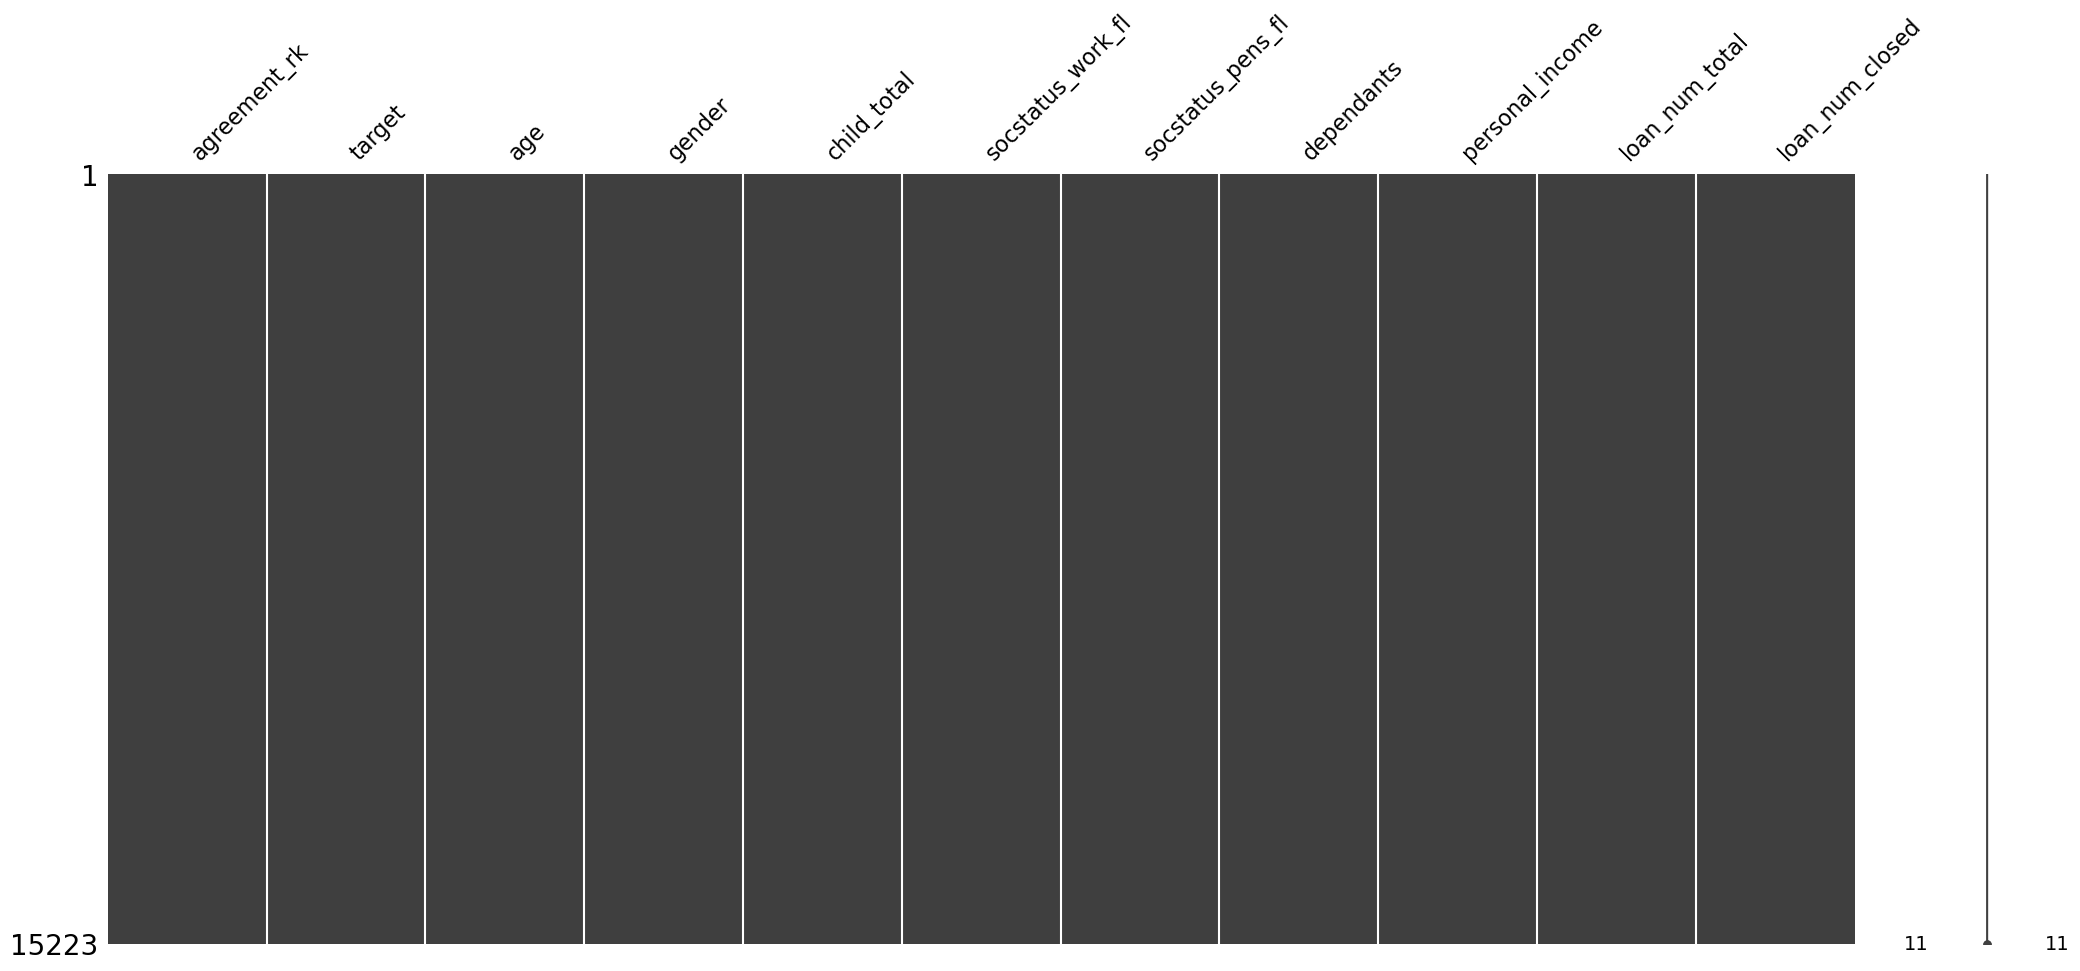

In [6]:
msno.matrix(df); #Матрица пропущенных значений

In [7]:
# Пропущенных значений нет

In [8]:
print(df.dtypes)

agreement_rk         float64
target               float64
age                  float64
gender               float64
child_total          float64
socstatus_work_fl    float64
socstatus_pens_fl    float64
dependants           float64
personal_income      float64
loan_num_total         int64
loan_num_closed      float64
dtype: object


In [9]:
columns_int = ['agreement_rk', 'target', 'age', 'gender', 'child_total', 'socstatus_work_fl', 'socstatus_pens_fl', 
               'dependants', 'loan_num_total', 'loan_num_closed']
for elem in columns_int:
    df[elem] = df[elem].astype(int)
print(df.dtypes)

agreement_rk           int32
target                 int32
age                    int32
gender                 int32
child_total            int32
socstatus_work_fl      int32
socstatus_pens_fl      int32
dependants             int32
personal_income      float64
loan_num_total         int32
loan_num_closed        int32
dtype: object


In [10]:
df.describe()

,agreement_rk,target,age,gender,child_total,socstatus_work_fl,socstatus_pens_fl,dependants,personal_income,loan_num_total,loan_num_closed
count,1.522300e+04,15223.000000,15223.000000,15223.000000,15223.000000,15223.000000,15223.000000,15223.000000,15223.000000,15223.000000,15223.000000
mean,6.540183e+07,0.119030,40.406096,0.654536,1.099389,1.909610,1.134468,0.645208,13853.836323,1.414636,0.766406
std,4.568181e+06,0.323835,11.601068,0.475535,0.995411,0.286748,0.341165,0.812252,9015.467617,0.839538,1.024446
min,5.991015e+07,0.000000,21.000000,0.000000,0.000000,1.000000,1.000000,0.000000,24.000000,1.000000,0.000000
25%,6.192092e+07,0.000000,30.000000,0.000000,0.000000,2.000000,1.000000,0.000000,8000.000000,1.000000,0.000000
50%,6.437100e+07,0.000000,39.000000,1.000000,1.000000,2.000000,1.000000,0.000000,12000.000000,1.000000,0.000000
75%,6.708802e+07,0.000000,50.000000,1.000000,2.000000,2.000000,1.000000,1.000000,17000.000000,2.000000,1.000000
max,7.529224e+07,1.000000,67.000000,1.000000,10.000000,2.000000,2.000000,7.000000,250000.000000,16.000000,16.000000


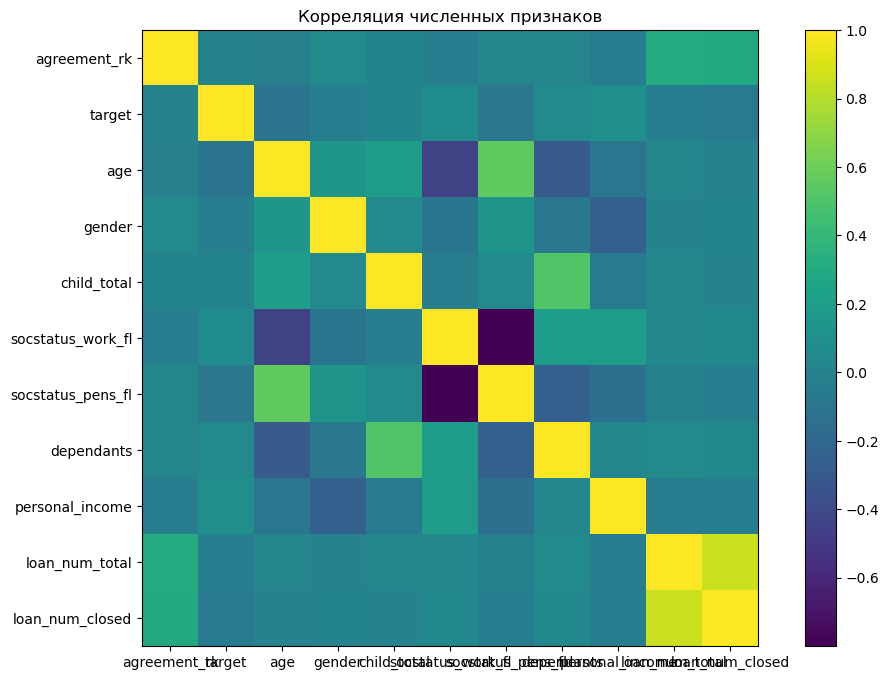

In [11]:
plt.figure(figsize=(12, 8))

columns = df.corr().columns.tolist()
plt.imshow(df.corr())

plt.title("Корреляция численных признаков")
plt.xticks(range(0, len(columns)), columns)
plt.yticks(range(0, len(columns)), columns)
plt.colorbar()
plt.show()

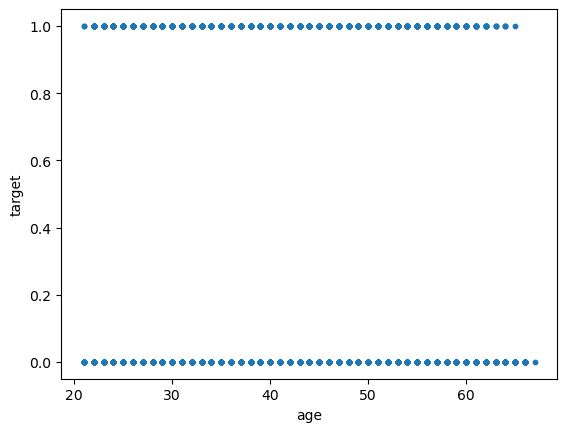

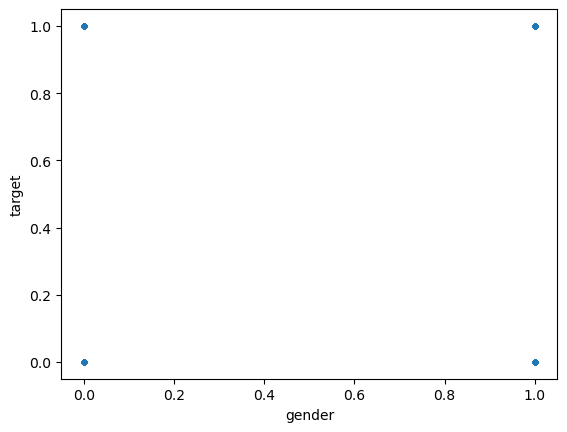

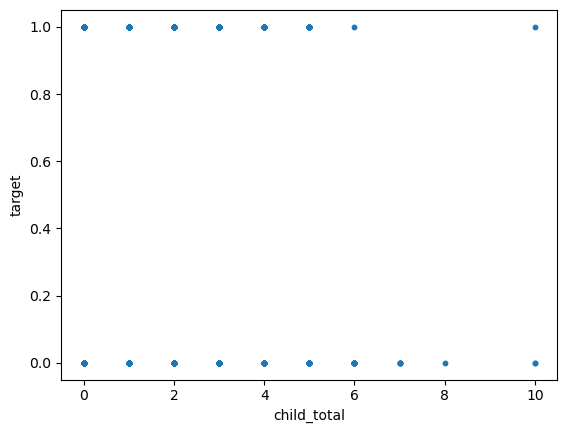

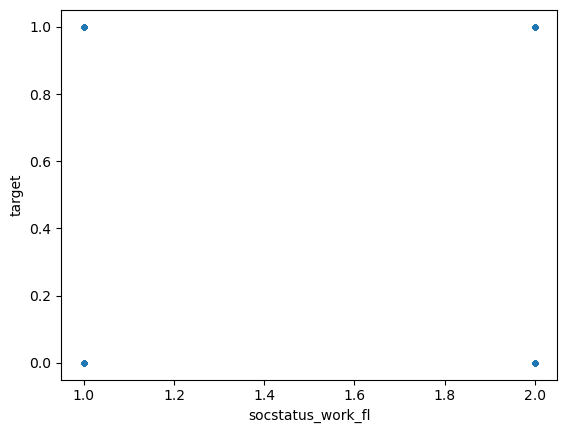

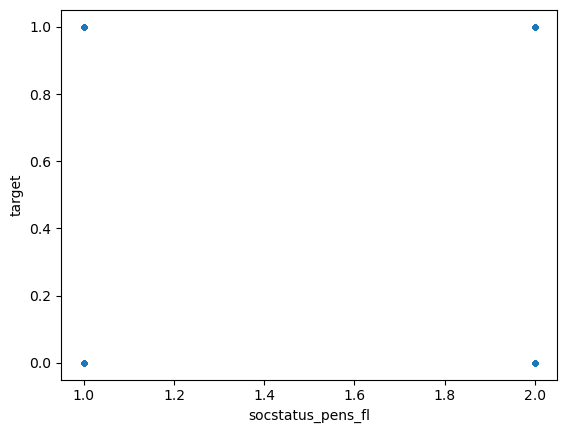

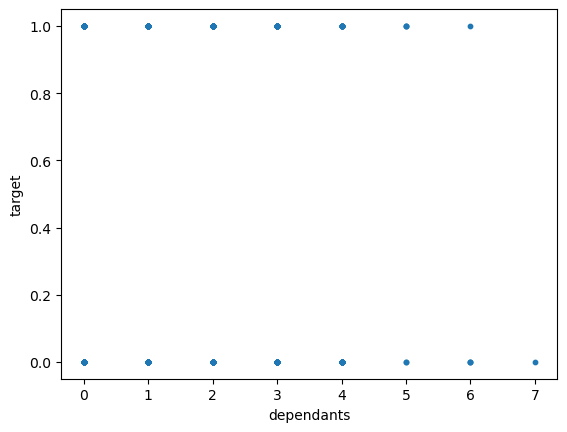

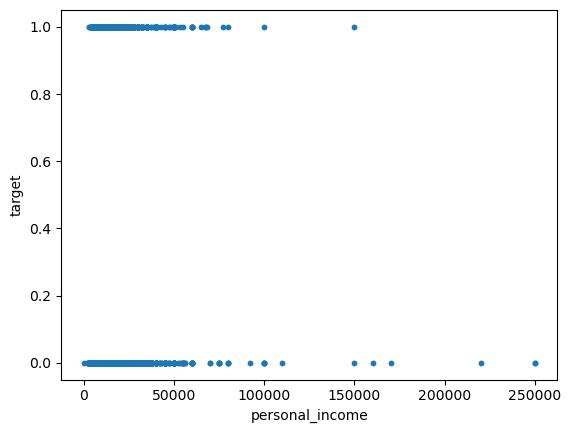

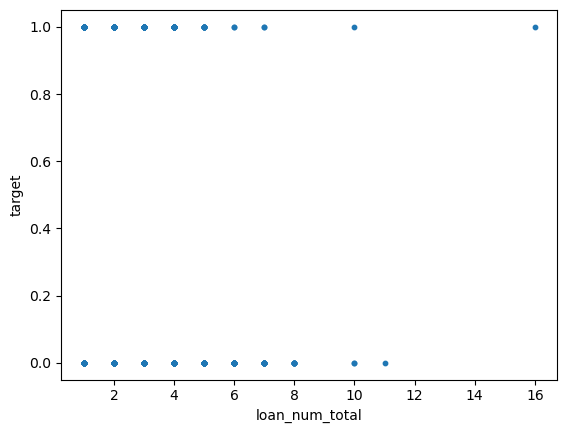

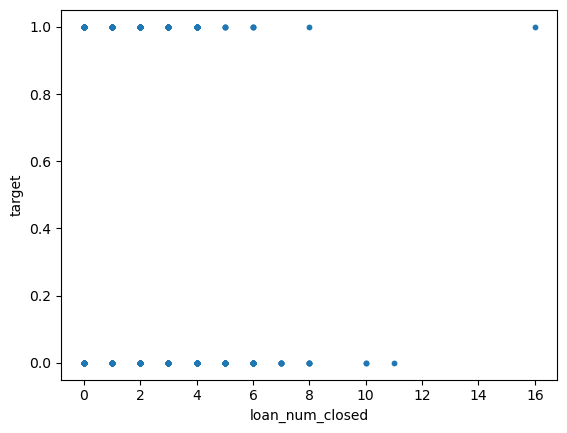

In [12]:
### Ваш код здесь ###
X = df.drop(['agreement_rk', 'target'], axis=1)
y = df['target']

numerical_features = X.select_dtypes(include=['int32', 'int64', 'float64']).columns

for elem in numerical_features:
    plt.scatter(X[elem], y, s=10)
    #df = df.sort_values('x')
    plt.xlabel(elem)
    plt.ylabel('target')
    plt.show()

<Axes: >

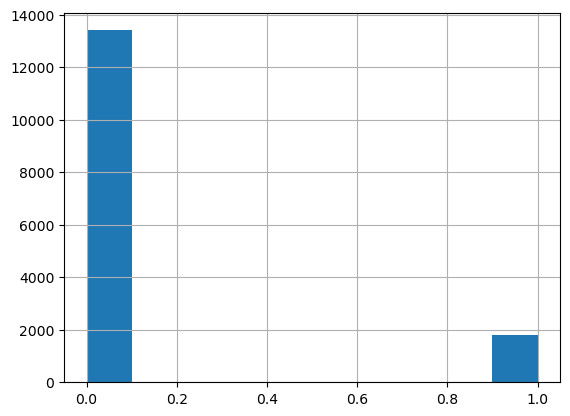

In [13]:
df['target'].hist()

Генерируем новые признаки
Доля погашенных ссуд от общего количества ссуд клиента: LOAN_NUM_CLOSED / LOAN_NUM_TOTAL.
Возраст клиента в категориях
Доход клиента в категориях
Бинарный признак "Более 1 ребенка" в зависимости от количества детей клиента: 1, если CHILD_TOTAL > 1, иначе 0.
Бинарный признак "Высокий доход" в зависимости от личного дохода клиента: 1, если PERSONAL_INCOME > средний доход, иначе 0.
Бинарный признак "Молодой возраст" в зависимости от возраста клиента: 1, если возраст < 30, иначе 0.

In [14]:
def calculate_proport(A, B):
    if B > 0:
        return A / B
    else:
        return 0
    
df['prop_loan_closed'] = df.apply(lambda x: calculate_proport(x['loan_num_closed'], x['loan_num_total']),axis=1)


In [15]:
q25 = df.age.quantile(0.25)
q75 = df.age.quantile(0.75)
df['age_cat'] = df['age'].apply(lambda x: 0.0 if x < q25 else (1.0 if x > q75 else 0.5))

q25 = df.personal_income.quantile(0.25)
q75 = df.personal_income.quantile(0.75)
df['personal_income_cat'] = df['personal_income'].apply(lambda x: 0.0 if x < q25 else (1.0 if x > q75 else 0.5))

In [16]:
df['more_one_child'] = df['child_total'].apply(lambda x: 1.0 if x > 1 else 0)
df['high_pers_income'] = df['personal_income'].apply(lambda x: 1.0 if x > df.personal_income.mean() else 0)
df['young_age'] = df['age'].apply(lambda x: 1.0 if x < 30 else 0)

In [17]:
df

,agreement_rk,target,age,gender,child_total,socstatus_work_fl,socstatus_pens_fl,dependants,personal_income,loan_num_total,loan_num_closed,prop_loan_closed,age_cat,personal_income_cat,more_one_child,high_pers_income,young_age
0,59910150,0,49,1,2,2,1,1,5000.0,2,2,1.000000,0.5,0.0,1.0,0.0,0.0
1,59910230,0,32,1,3,2,1,3,12000.0,1,1,1.000000,0.5,0.5,1.0,0.0,0.0
2,59910525,0,52,1,4,2,1,0,9000.0,2,1,0.500000,1.0,0.5,1.0,0.0,0.0
3,59910803,0,39,1,1,2,1,1,25000.0,1,1,1.000000,0.5,1.0,0.0,1.0,0.0
4,59911781,0,30,0,0,2,1,0,12000.0,2,1,0.500000,0.5,0.5,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15218,75291424,0,25,0,1,2,1,1,12000.0,3,2,0.666667,0.0,0.5,0.0,0.0,1.0
15219,75291888,0,51,1,2,2,1,0,10000.0,1,0,0.000000,1.0,0.5,1.0,0.0,0.0
15220,75291923,0,22,1,1,2,1,1,6000.0,1,0,0.000000,0.0,0.0,0.0,0.0,1.0
15221,75291960,0,60,1,2,1,2,0,4500.0,1,0,0.000000,1.0,0.0,1.0,0.0,0.0


In [18]:
# раздедлите на обучающую и тестовую выборки

# Ваш код здесь
X = df.drop(['agreement_rk', 'target'], axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=63)

In [19]:
score_list = []
loo = LeaveOneOut()
for k in range(11, 41, 2):
    model_knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(model_knn, X_train, y_train,
                         scoring='accuracy',
                         cv=loo, n_jobs=-1)
    score_list.append([k, scores.mean()])

In [20]:
score_df = pd.DataFrame(score_list, columns=['k', 'score'])

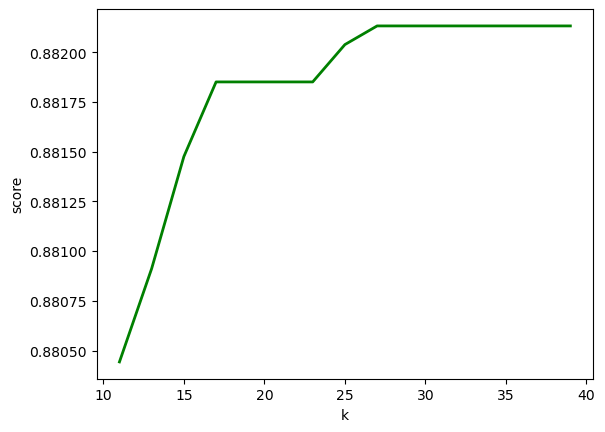

In [21]:
plt.plot(score_df['k'], score_df['score'], linewidth=2, color='g')
plt.xlabel('k')
plt.ylabel('score')
plt.show()

In [22]:
score_df[score_df['score'] == score_df['score'].max()]

,k,score
8,27,0.882132
9,29,0.882132
10,31,0.882132
11,33,0.882132
12,35,0.882132
13,37,0.882132
14,39,0.882132


In [28]:
model_knn = KNeighborsClassifier(n_neighbors=27)
model_knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=27)

In [29]:
y_pred = model_knn.predict(X_train)

In [30]:
# проверьте качество модели с помощью F-мера

# Ваш код здесь
res = classification_report(y_train, y_pred)
print(res)

              precision    recall  f1-score   support

           0       0.88      1.00      0.94      9400
           1       0.00      0.00      0.00      1256

    accuracy                           0.88     10656
   macro avg       0.44      0.50      0.47     10656
weighted avg       0.78      0.88      0.83     10656



C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [31]:
# проверьте качество модели с помощью матрицы сопряжённостей

# Ваш код здесь
confusion_matrix(y_train, y_pred)

array([[9400,    0],
       [1256,    0]], dtype=int64)

In [32]:
confusion_matrix(y_test, model_knn.predict(X_test))

array([[4011,    0],
       [ 556,    0]], dtype=int64)

    # сделайте вывод о работе модели

    # Ваш текст здесь
    
    Модель показала достаточно хорошую точность, но из-за высокого дисбаланса классов способность предсказания события TARGET, когда отклик был бы зарегистрирован практически нулевая. В случае неравных классов нужно подбирать баланс классов для обучения и метрику, которая будет корректно отражать качество классификации, либо вычислять порог(threshold) предсказания согласно логике решения задачи